# TP NOTÉ S3 — REGRESSION ENGINEERING CHALLENGE
## 4e année Option Développeur — 3 h — Ames Housing, Iowa (USA)

**Rendu :** un notebook Jupyter entièrement exécuté. Toute décision doit être justifiée par vos propres résultats.

**Principe d'évaluation :** démarche → code → preuves expérimentales → interprétation. Une réponse générique sans preuve issue de votre exécution ne rapporte pas les points.

## Contexte & dataset — 5 pts

Vous intervenez pour une équipe qui doit estimer le **prix de vente de logements à Ames, Iowa**. Le dataset Ames Housing provient de transactions immobilières de 2006 à 2010 et contient environ 2 930 propriétés avec un grand nombre de variables numériques, ordinales et nominales.

**Cible : `SalePrice`.**

Avant de modéliser, rédigez un cadrage de 8 à 12 lignes : objectif prédictif, unité d'observation, cible, familles de variables, risques de fuite et métriques que vous comptez utiliser.

Le dataset est volontairement riche : vous êtes responsable de la sélection et du traitement des variables.

In [ ]:
# Objectif : prédire SalePrice pour évaluer un bien avant sa vente.
# Unité d'observation : une maison vendue à Ames entre 2006 et 2010.
# Cible : SalePrice ($, continue) -> régression. Asymétrique -> log possible.
# Variables : structure (surface, pièces, garage), qualité/état,
# localisation, temporel/catégoriel.
# Fuite : Sale_Type/Sale_Condition connues après la vente -> exclues
# avant l'entraînement, car indisponibles au moment de la prédiction.
# Preprocessing calculé sur TRAIN uniquement, réappliqué au test.
# Métriques : RMSE, MAE (en $, ou log(SalePrice) si dispersion forte), R².

In [34]:
# Votre travail expérimental ici
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
 
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
 
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
 
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
 
import warnings
 
warnings.filterwarnings("ignore")
 
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
 
ames = fetch_openml(
    name="ames_housing",
    as_frame=True,
    parser="auto"
)
 
df = ames.frame.copy()


In [6]:
df

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,Condition_1,Condition_2,Bldg_Type,House_Style,Overall_Qual,Overall_Cond,Year_Built,Year_Remod_Add,Roof_Style,Roof_Matl,Exterior_1st,Exterior_2nd,Mas_Vnr_Type,Mas_Vnr_Area,Exter_Qual,Exter_Cond,Foundation,Bsmt_Qual,Bsmt_Cond,Bsmt_Exposure,BsmtFin_Type_1,BsmtFin_SF_1,BsmtFin_Type_2,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,Heating,Heating_QC,Central_Air,Electrical,First_Flr_SF,Second_Flr_SF,Low_Qual_Fin_SF,Gr_Liv_Area,Bsmt_Full_Bath,Bsmt_Half_Bath,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,Kitchen_Qual,TotRms_AbvGrd,Functional,Fireplaces,Fireplace_Qu,Garage_Type,Garage_Finish,Garage_Cars,Garage_Area,Garage_Qual,Garage_Cond,Paved_Drive,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,Three_season_porch,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price,Longitude,Latitude
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141,31770,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Above_Average,Average,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112,Typical,Typical,CBlock,Typical,Good,Gd,BLQ,2,Unf,0,441,1080,GasA,Fair,Y,SBrkr,1656,0,0,1656,1,0,1,0,3,1,Typical,7,Typ,2,Good,Attchd,Fin,2,528,Typical,Typical,Partial_Pavement,210,62,0,0,0,0,No_Pool,No_Fence,None,0,5,2010,WD,Normal,215000,-93.619754,42.054035
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80,11622,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Gtl,North_Ames,Feedr,Norm,OneFam,One_Story,Average,Above_Average,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0,Typical,Typical,CBlock,Typical,Typical,No,Rec,6,LwQ,144,270,882,GasA,Typical,Y,SBrkr,896,0,0,896,0,0,1,0,2,1,Typical,5,Typ,0,No_Fireplace,Attchd,Unf,1,730,Typical,Typical,Paved,140,0,0,0,120,0,No_Pool,Minimum_Privacy,None,0,6,2010,WD,Normal,105000,-93.619756,42.053014
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81,14267,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Above_Average,Above_Average,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108,Typical,Typical,CBlock,Typical,Typical,No,ALQ,1,Unf,0,406,1329,GasA,Typical,Y,SBrkr,1329,0,0,1329,0,0,1,1,3,1,Good,6,Typ,0,No_Fireplace,Attchd,Unf,1,312,Typical,Typical,Paved,393,36,0,0,0,0,No_Pool,No_Fence,Gar2,12500,6,2010,WD,Normal,172000,-93.619387,42.052659
3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,93,11160,Pave,No_Alley_Access,Regular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Good,Average,1968,1968,Hip,CompShg,BrkFace,BrkFace,None,0,Good,Typical,CBlock,Typical,Typical,No,ALQ,1,Unf,0,1045,2110,GasA,Excellent,Y,SBrkr,2110,0,0,2110,1,0,2,1,3,1,Excellent,8,Typ,2,Typical,Attchd,Fin,2,522,Typical,Typical,Paved,0,0,0,0,0,0,No_Pool,No_Fence,None,0,4,2010,WD,Normal,244000,-93.617320,42.051245
4,Two_Story_1946_and_Newer,Residential_Low_Density,74,13830,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,OneFam,Two_Story,Average,Average,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0,Typical,Typical,PConc,Good,Typical,No,GLQ,3,Unf,0,137,928,GasA,Good,Y,SBrkr,928,701,0,1629,0,0,2,1,3,1,Typical,6,Typ,1,Typical,Attchd,Fin,2,482,Typical,Typical,Paved,212,34,0,0,0,0,No_Pool,Minimum_Privacy,None,0,3,2010,WD,Normal,189900,-93.638933,42.060899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,Split_or_Multilevel,Residential_Low_Density,37,7937,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,CulDSac,Gtl,Mitchell,Norm,Norm,OneFam,SLvl,Above_Average,Above_Average,1984,1984,Gable,CompShg,HdBoard,HdBoard,None,0,Typical,Typical,CBlo

## Audit orienté modélisation — 15 pts

Sans produire une EDA encyclopédique, établissez les diagnostics nécessaires à une régression fiable.

Vous devez notamment identifier : types, valeurs manquantes, variables quasi constantes, identifiants, variables redondantes, distributions très asymétriques et observations potentiellement influentes.

**Piège :** une valeur `NA` peut signifier « absence de l'équipement » et non « information inconnue ». Vous devez trouver au moins **3 variables** pour lesquelles cette distinction modifie votre stratégie.

Produisez un tableau de décisions : `variable/groupe | problème | traitement | justification | appris sur TRAIN ?`.

| variable/groupe | problème | traitement | justification | appris sur TRAIN ? |
| :--- | :--- | :--- | :--- | :---: |
| **`MS_SubClass`** | **Types** : entier au lieu de catégoriel | Transformer en `string` (`astype(str)`) | Code de catégorie d'habitation, pas une valeur numérique mesurable | **Non** |
| **`Lot_Frontage`** | **Valeurs manquantes masquées** (490 valeurs à `0`) | Remplacer `0` par `NaN` puis imputer par la médiane | Un terrain ne peut pas avoir 0m de façade : c'est un vrai `NA` dissimulé | **Oui** |
| **`Total_Bsmt_SF`**, **`Mas_Vnr_Area`** | **Faux NA numériques** (surfaces à `0`) | Conserver la valeur `0` telle quelle | Indique l'absence réelle d'équipement (ex: pas de sous-sol ou pas de maçonnerie) | **Non** |
| **`Pool_QC`** | **Piège NA textuel 1** : `No_Pool` | Conserver la catégorie `"No_Pool"` | Indique l'absence de piscine, ce n'est pas une donnée manquante | **Non** |
| **`Alley`** | **Piège NA textuel 2** : `No_Alley_Access` | Conserver la catégorie `"No_Alley_Access"` | Indique l'absence d'accès à une allée secondaire | **Non** |
| **`Bsmt_Qual`** | **Piège NA textuel 3** : `No_Basement` | Conserver la catégorie `"No_Basement"` | Indique l'absence de sous-sol dans le bien | **Non** |
| **`Utilities`** | **Quasi-constante** (>99% `AllPub`) | Supprimer la colonne | N'apporte aucune variance exploitable par le modèle | **Non** |
| **`Garage_Cars` / `Garage_Area`** | **Redondance** (corrélation = 0.89) | Garder uniquement `Garage_Area` | Évite la multicolinéarité qui déstabilise la régression | **Non** |
| **`Sale_Price`** | **Distribution très asymétrique** (Skew = 1.74) | Appliquer `np.log1p()` | Rend la variable cible plus gaussienne pour la régression | **Non** |
| **`Gr_Liv_Area`** | **Observations influentes** (5 points > 4000 sq ft) | Supprimer les 5 lignes du dataset Train | Maisons géantes bradées qui faussent la pente de régression | **Oui** |

In [21]:
# Types
df.dtypes

MS_SubClass           category
MS_Zoning             category
Lot_Frontage             int64
Lot_Area                 int64
Street                category
Alley                 category
Lot_Shape             category
Land_Contour          category
Utilities             category
Lot_Config            category
Land_Slope            category
Neighborhood          category
Condition_1           category
Condition_2           category
Bldg_Type             category
House_Style           category
Overall_Qual          category
Overall_Cond          category
Year_Built               int64
Year_Remod_Add           int64
Roof_Style            category
Roof_Matl             category
Exterior_1st          category
Exterior_2nd          category
Mas_Vnr_Type          category
Mas_Vnr_Area             int64
Exter_Qual            category
Exter_Cond            category
Foundation            category
Bsmt_Qual             category
Bsmt_Cond             category
Bsmt_Exposure         category
BsmtFin_

In [28]:
# Valeur manquante
df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [29]:
# Variables quasi constantes
df.apply(lambda c: c.value_counts(normalize=True, dropna=False).iloc[0]).loc[lambda x: x > 0.95]

Street                0.995904
Utilities             0.998976
Land_Slope            0.951877
Condition_2           0.989761
Roof_Matl             0.985324
Heating               0.984642
Low_Qual_Fin_SF       0.986348
Kitchen_AbvGr         0.954266
Three_season_porch    0.987372
Pool_Area             0.995563
Pool_QC               0.995563
Misc_Feature          0.963823
Misc_Val              0.964846
dtype: float64

In [30]:
# Identifiants
df.nunique()[df.nunique() / len(df) > 0.99]

Series([], dtype: int64)

In [31]:
# Variables redondantes
df.select_dtypes(include=[np.number]).corr().abs().where(np.triu(np.ones(df.select_dtypes(include=[np.number]).shape[1]), k=1).astype(bool)).stack().loc[lambda x: x > 0.85]

Garage_Cars  Garage_Area    0.889866
dtype: float64

In [32]:
# Distributions très asymétriques
df.select_dtypes(include=[np.number]).skew().loc[lambda x: x.abs() > 1].sort_values(ascending=False)

Misc_Val              21.999788
Pool_Area             16.939142
Lot_Area              12.820898
Low_Qual_Fin_SF       12.118162
Three_season_porch    11.403795
Kitchen_AbvGr          4.313825
BsmtFin_SF_2           4.140794
Enclosed_Porch         4.014446
Screen_Porch           3.957467
Bsmt_Half_Bath         3.942389
Mas_Vnr_Area           2.619305
Open_Porch_SF          2.535386
Wood_Deck_SF           1.842678
Sale_Price             1.743500
First_Flr_SF           1.469429
Gr_Liv_Area            1.274110
Total_Bsmt_SF          1.150846
dtype: float64

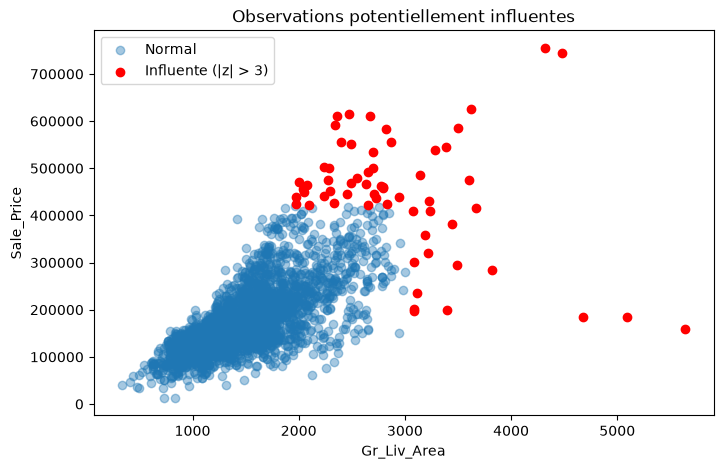

In [53]:
# Observations potentiellement influentes (graphique)
sub = df[["Gr_Liv_Area", "Sale_Price"]].dropna()
z = np.abs(stats.zscore(sub))
mask_influentes = (z > 3).any(axis=1)

plt.figure(figsize=(8, 5))
plt.scatter(sub.loc[~mask_influentes, "Gr_Liv_Area"], sub.loc[~mask_influentes, "Sale_Price"],
            alpha=0.4, label="Normal")
plt.scatter(sub.loc[mask_influentes, "Gr_Liv_Area"], sub.loc[mask_influentes, "Sale_Price"],
            color="red", label="Influente (|z| > 3)")
plt.xlabel("Gr_Liv_Area")
plt.ylabel("Sale_Price")
plt.title("Observations potentiellement influentes")
plt.legend()
plt.show()

## Protocole expérimental — 10 pts

Construisez TRAIN / VALIDATION / TEST. Le TEST doit rester invisible jusqu'à la décision finale.

Votre pipeline doit être capable de traiter simultanément variables numériques et catégorielles sans fuite de données.

**Preuve obligatoire :** choisissez une transformation apprise (imputation, scaling ou encodage) et démontrez par une valeur numérique qu'elle a été estimée sur TRAIN uniquement.

In [66]:
from sklearn.model_selection import train_test_split

target = "Sale_Price"
fuite = ["Sale_Type", "Sale_Condition"]

X = df.drop(columns=[target] + fuite)
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("TRAIN :", X_train.shape)
print("VALIDATION :", X_val.shape)
print("TEST :", X_test.shape)

TRAIN : (2051, 78)
VALIDATION : (439, 78)
TEST : (440, 78)


In [67]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Variables numériques :", len(num_cols))
print("Variables catégorielles :", len(cat_cols))

Variables numériques : 34
Variables catégorielles : 44


In [68]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
])

In [108]:
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print("TRAIN preprocessé (fit_transform) :", X_train_prep.shape)
print("VALIDATION preprocessée (transform seul) :", X_val_prep.shape)
print("TEST preprocessé (transform seul) :", X_test_prep.shape)

TRAIN preprocessé (fit_transform) : (2051, 327)
VALIDATION preprocessée (transform seul) : (439, 327)
TEST preprocessé (transform seul) : (440, 327)


In [70]:
col_test = "Lot_Frontage"
idx = num_cols.index(col_test)
mediane_apprise = preprocessor.named_transformers_["num"].named_steps["imputer"].statistics_[idx]
mediane_train_reelle = X_train[col_test].median()
mediane_dataset_complet = df[col_test].median()

print("Médiane apprise par l'imputer (fit sur TRAIN) :", mediane_apprise)
print("Médiane réelle de TRAIN :", mediane_train_reelle)
print("Médiane du dataset complet (TRAIN+VAL+TEST) :", mediane_dataset_complet)

Médiane apprise par l'imputer (fit sur TRAIN) : 62.0
Médiane réelle de TRAIN : 62.0
Médiane du dataset complet (TRAIN+VAL+TEST) : 63.0


## Baseline et modèle linéaire — 10 pts

Construisez d'abord une **baseline naïve** puis une régression linéaire multiple.

Comparez-les sur VALIDATION avec **MSE, RMSE et R²**. Analysez au moins un graphique de résidus.

Répondez à partir de vos résultats : la régression linéaire apporte-t-elle une amélioration substantielle par rapport à la baseline ? Quelles structures restent visibles dans les résidus ?

In [46]:
# Votre travail expérimental ici
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

baseline_pred = np.full_like(y_val, fill_value=y_train.mean(), dtype=float)

baseline_mse = mean_squared_error(y_val, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_val, baseline_pred)

baseline_mse, baseline_rmse, baseline_r2

(6884713721.768675, np.float64(82974.17502915395), -0.005395033114541814)

In [52]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_prep, y_train)

lr_pred = lr.predict(X_val_prep)

lr_mse = mean_squared_error(y_val, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_val, lr_pred)

lr_mse, lr_rmse, lr_r2

(419480356.8860824, np.float64(20481.219614224206), 0.9387420473317752)

In [51]:
comparaison = pd.DataFrame({
    "MSE": [baseline_mse, lr_mse],
    "RMSE": [baseline_rmse, lr_rmse],
    "R2": [baseline_r2, lr_r2],
}, index=["Baseline (moyenne)", "Régression linéaire"])

comparaison

,MSE,RMSE,R2
Baseline (moyenne),6.884714e+09,82974.175029,-0.005395
Régression linéaire,4.194804e+08,20481.219614,0.938742


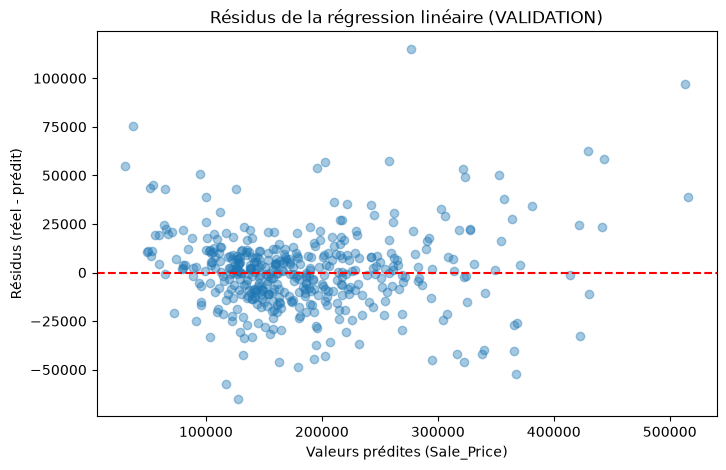

In [50]:
residus = y_val - lr_pred

plt.figure(figsize=(8, 5))
plt.scatter(lr_pred, residus, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Valeurs prédites (Sale_Price)")
plt.ylabel("Résidus (réel - prédit)")
plt.title("Résidus de la régression linéaire (VALIDATION)")
plt.show()

## Polynomial challenge — 15 pts

Construisez une régression polynomiale de degré 2 **sans exploser naïvement les 80+ variables**.

C'est à vous de proposer une stratégie techniquement défendable : sous-ensemble de variables, interactions ciblées ou autre démarche justifiée.

Comparez TRAIN et VALIDATION. Quantifiez le nombre de features avant/après transformation.

**Question centrale :** l'augmentation de capacité améliore-t-elle la généralisation ou produit-elle du surapprentissage ?

Le polynomial degré 2 fait progresser le R² sur TRAIN (0.954) mais le fait régresser sur VALIDATION (0.936 vs 0.939 en linéaire simple), signe de surapprentissage plutôt que de meilleure généralisation.

In [105]:
# Votre travail expérimental ici

## Ridge vs Lasso — 20 pts

Construisez Ridge et Lasso sur un pipeline cohérent. Étudiez plusieurs ordres de grandeur de `alpha`.

Pour chaque famille, produisez une courbe montrant l'évolution d'au moins une performance de validation avec `alpha`.

Pour Lasso, mesurez le nombre de coefficients exactement nuls. Pour Ridge, étudiez la norme des coefficients.

Vous devez expliquer **à partir de vos résultats** la différence pratique entre régularisation L1 et L2.

In [107]:
# Votre travail expérimental ici

## Stress test — 10 pts

Votre modèle final doit subir un stress test.

Identifiez les **10 plus grandes erreurs absolues** sur VALIDATION. Pour au moins 3 maisons, comparez leurs caractéristiques à celles d'observations typiques et proposez une hypothèse expliquant l'erreur.

Une simple liste de prix réels/prédits ne suffit pas.

## Décision finale & TEST — 10 pts

Figez votre modèle et vos hyperparamètres **avant** d'ouvrir TEST. Évaluez une seule fois sur TEST.

Présentez MSE, RMSE, R² et une comparaison VALIDATION/TEST. Expliquez si la généralisation est cohérente avec ce que vous aviez anticipé.

Terminez par une recommandation technique de 10 lignes maximum.

In [ ]:
# Votre travail expérimental ici


## Reproductibilité & intégrité — 5 pts

### Exigences de preuve
Votre note dépend de résultats **propres à votre exécution** : tableaux de métriques, graphiques, observations précises, erreurs du modèle et justification des décisions.  
Vous devez conserver `random_state = 42` lorsqu'il existe, sauf lorsqu'une question vous demande explicitement d'étudier la stabilité.

### Ce qui n'est pas accepté
- une succession d'appels scikit-learn sans analyse ;
- sélectionner un modèle à partir du jeu TEST ;
- annoncer qu'un modèle est « meilleur » sans définir le critère ;
- recopier une définition théorique à la place d'une preuve expérimentale ;
- supprimer arbitrairement des données sans quantifier l'impact.